# Ridewise-Churn Modeling & Evaluation
- purpose: train another model to predict which rider will churn, evaluated their performance and select the best

### Models:


- Logistic regression (simple,fast, interpretble)-- Baseline model
- random forest classifier --- more robust, can handle non-linear relationship
- Xgboost ---- often best perfomance(advance model)-- handle imbalance dataset

### STEP 1 - Setp and Load data

In [84]:
import os
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)


# define the data paths
DATA_PROCESSED = os.path.join("..", "data", "processed")
MODEL_DIR = os.path.join("..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

# load data
df = pd.read_csv(
    os.path.join(
        DATA_PROCESSED,
        "ridewise_features.csv"
    )
)

df.head()

,user_id,account_age_days,age,city,loyalty_status,avg_rating_given,was_referred,frequency,monetary_total,average_fare,...,avg_tip,avg_tip_rate,peak_trip_ratio,weekend_trip_ratio,rainy_trip_ratio,preferred_payment,avg_driver_rating,avg_driver_acceptance_rate,preferred_vehicle,churned
0,R00000,33,35,Nairobi,Bronze,5.0,1,24,349.74,14.572500,...,0.167917,0.012193,0.208333,0.166667,0.166667,Mobile Money,4.241667,0.699978,SUV,0
1,R00001,170,35,Nairobi,Bronze,4.7,0,11,138.24,12.567273,...,0.007273,0.000823,0.181818,0.181818,0.000000,Card,4.145455,0.718857,Sedan,0
2,R00002,172,47,Lagos,Bronze,4.2,0,20,328.09,16.404500,...,0.260500,0.021981,0.450000,0.100000,0.300000,Card,4.110000,0.612854,Sedan,0
3,R00004,190,41,Lagos,Silver,3.9,1,14,236.95,16.925000,...,0.670000,0.066116,0.285714,0.500000,0.214286,Mobile Money,4.214286,0.758234,Sedan,0
4,R00005,597,40,Lagos,Bronze,5.0,0,17,249.76,14.691765,...,0.213529,0.010792,0.411765,0.117647,0.058824,Mobile Money,4.023529,0.677242,Sedan,0


### STEP 2 - Inspect the Data

In [85]:
# step 2a inspect datatype
print(f"Dataset Shape: {df.shape}")
print(df.info())
print(df.describe())

Dataset Shape: (9204, 31)
<class 'pandas.DataFrame'>
RangeIndex: 9204 entries, 0 to 9203
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   user_id                     9204 non-null   str    
 1   account_age_days            9204 non-null   int64  
 2   age                         9204 non-null   int64  
 3   city                        9204 non-null   str    
 4   loyalty_status              9204 non-null   str    
 5   avg_rating_given            9204 non-null   float64
 6   was_referred                9204 non-null   int64  
 7   frequency                   9204 non-null   int64  
 8   monetary_total              9204 non-null   float64
 9   average_fare                9204 non-null   float64
 10  recency_days                9204 non-null   int64  
 11  average_spend_per_trip      9204 non-null   float64
 12  account_age_months          9204 non-null   float64
 13  trip_frequency_mon

In [86]:

# step 2b - Check Missing Values
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

missing[missing > 0]


Series([], dtype: int64)

In [87]:
# step 2c - Check Class Distribution
(
    df["churned"]
    .value_counts()
)
(
    df["churned"]
    .value_counts(normalize=True)
    * 100
).round(2)


churned
0    96.13
1     3.87
Name: proportion, dtype: float64

In [88]:
### Observation

# The dataset is imbalanced, with fewer churned customers than active customers.

# To address this during modelling:

# Use a stratified train-test split.
# Apply class weighting where appropriate.
# Evaluate using Precision, Recall, F1-score and ROC-AUC rather than Accuracy alone.

### STEP 3 - Define Future and Target

In [89]:
# step 3a - define target and features
X = df.drop(
    columns=[
        "user_id",
        "churned"
    ]
)

y = df["churned"]

In [90]:
# step 3b - Identify Numerical and Categorical Features

numeric_features = (
    X.select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

categorical_features = (
    X.select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)

print("Numerical Features")
print(numeric_features)

print()

print("Categorical Features")
print(categorical_features)

Numerical Features
['account_age_days', 'age', 'avg_rating_given', 'was_referred', 'frequency', 'monetary_total', 'average_fare', 'recency_days', 'average_spend_per_trip', 'account_age_months', 'trip_frequency_monthly', 'customer_lifetime_value', 'trips_last_30_days', 'trips_last_60_days', 'avg_days_between_trips', 'trips_last_90_days', 'avg_trip_duration', 'avg_surge_multiplier', 'avg_tip', 'avg_tip_rate', 'peak_trip_ratio', 'weekend_trip_ratio', 'rainy_trip_ratio', 'avg_driver_rating', 'avg_driver_acceptance_rate']

Categorical Features
['city', 'loyalty_status', 'preferred_payment', 'preferred_vehicle']


### STEP 4 - Train - Test Split

In [91]:
# step 4a - Train-Test Split

# The dataset is split into training and testing sets before any preprocessing.

# This ensures that information from the test set is not used during model training, preventing data leakage.

# A stratified split is used because churn is an imbalanced classification problem. 

# Stratification preserves the same proportion of churned and non-churned customers in both the training and testing sets.


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Training Set : {X_train.shape}")
print(f"Testing Set  : {X_test.shape}")

Training Set : (7363, 29)
Testing Set  : (1841, 29)


In [92]:
# step 4c - Check the Class Distribution

print("Training Target Distribution")
print(y_train.value_counts(normalize=True).round(3))

print()

print("Testing Target Distribution")
print(y_test.value_counts(normalize=True).round(3))

Training Target Distribution
churned
0    0.961
1    0.039
Name: proportion, dtype: float64

Testing Target Distribution
churned
0    0.961
1    0.039
Name: proportion, dtype: float64



### STEP 5 - Preprocessing Pipeline

- To avoid data leakage, all preprocessing is performed within a scikit-learn pipeline.
- The preprocessing pipeline is fitted only on the training data and automatically applied to the test data.
 
- Includes:

- Median imputation for numerical features
- Most frequent imputation for categorical features
- Standard scaling for numerical variables
- One-hot encoding for categorical variables



In [93]:
# step 5a - Numerical Pipeline
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)
# step 5b -  Categorical Pipeline
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)
# step 5c - Combine Both Pipelines
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)


### STEP 6 - Baseline Model - Logistic Regression

- Logistic Regression is used as the baseline model because it is:

- Simple and interpretable
- Fast to train
- Less prone to overfitting
- A strong benchmark for evaluating more complex models

- Since customer churn is an imbalanced classification problem, `class_weight="balanced"` is used to assign greater importance to the minority class during training.

In [94]:
# step 6a - Create the Pipeline
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# step 6b - Train the Model
logistic_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [95]:
# step 6c - Make Predictions
# y_pred_lr → predicted class (0 or 1)
# y_prob_lr → predicted probability (needed for ROC-AUC, threshold tuning, and explainability)

y_pred_lr = logistic_pipeline.predict(X_test)

y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

In [96]:
# step 6d - Evaluate the Baseline Model
# Calculate Performance Metrics

logistic_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Score": [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_prob_lr)
    ]
})

logistic_results["Score"] = logistic_results["Score"].round(3)

logistic_results

,Metric,Score
0,Accuracy,0.498
1,Precision,0.041
2,Recall,0.535
3,F1 Score,0.076
4,ROC AUC,0.517


In [97]:
# step 6e - Classification Report
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.96      0.50      0.66      1770
           1       0.04      0.54      0.08        71

    accuracy                           0.50      1841
   macro avg       0.50      0.52      0.37      1841
weighted avg       0.93      0.50      0.63      1841




### STEP 7 - Baseline Model Evaluation visualization

- The Logistic Regression model is evaluated using:

- Confusion Matrix
- ROC Curve
- Precision-Recall Curve

- These visualizations provide a deeper understanding of model performance beyond summary metrics.

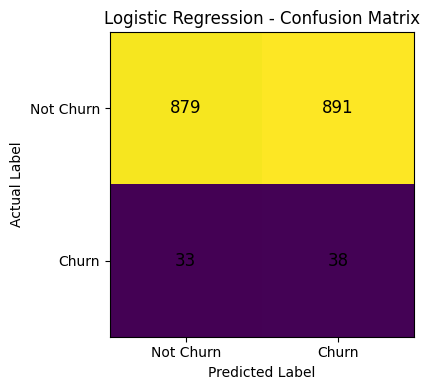

In [98]:
# step 7a - confusion metrix

cm = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(5, 4))

im = ax.imshow(cm)

ax.set_title("Logistic Regression - Confusion Matrix")

ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Not Churn", "Churn"])
ax.set_yticklabels(["Not Churn", "Churn"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=12
        )

plt.tight_layout()
plt.show()

### Insight

- The confusion matrix shows how many customers were correctly and incorrectly classified.

- Particular attention should be paid to False Negatives (customers predicted to stay but who actually churned), as these represent missed retention opportunities.

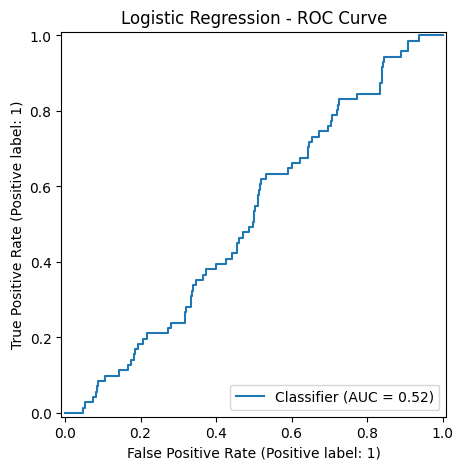

In [99]:
# step 7b - ROC Curve
fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    ax=ax
)

ax.set_title("Logistic Regression - ROC Curve")

plt.show()

### Insight

- The ROC curve illustrates the model's ability to distinguish between churned and non-churned customers across different probability thresholds.

- A larger area under the curve (ROC-AUC) indicates better discriminatory performance.

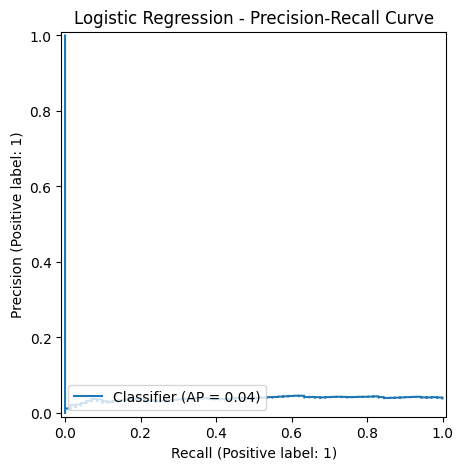

In [100]:
 # step 7c - Precision-Recall Curve
fig, ax = plt.subplots(figsize=(6, 5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_lr,
    ax=ax
)

ax.set_title("Logistic Regression - Precision-Recall Curve")

plt.show()



### Insight

The Precision-Recall curve is particularly useful for imbalanced datasets such as customer churn.

It illustrates the trade-off between identifying more churned customers (recall) and reducing false alarms (precision).

###  STEP 8 - Random Forest Classifier

- Random Forest is an ensemble learning algorithm that combines multiple decision trees.

- Compared with Logistic Regression, Random Forest can:

- Capture non-linear relationships
- Model interactions between variables
- Handle complex feature patterns
- Reduce overfitting through bagging
Build the Pipeline

In [101]:
# step 8a - create the pipeline

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [102]:
# step 8b - Train the Model
random_forest_pipeline.fit(
    X_train,
    y_train
)
# Make Predictions
y_pred_rf = random_forest_pipeline.predict(X_test)

y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [103]:
# step 8c - Evaluate the Model
random_forest_results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Score":[
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

random_forest_results["Score"] = (
    random_forest_results["Score"]
    .round(3)
)

random_forest_results

,Metric,Score
0,Accuracy,0.961
1,Precision,0.000
2,Recall,0.000
3,F1 Score,0.000
4,ROC AUC,0.484


In [104]:
# step 8d -  Classification Report
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1770
           1       0.00      0.00      0.00        71

    accuracy                           0.96      1841
   macro avg       0.48      0.50      0.49      1841
weighted avg       0.92      0.96      0.94      1841



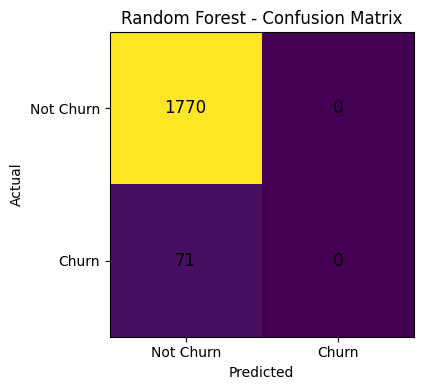

In [105]:
# step 8e -  Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(5,4))

im = ax.imshow(cm)

ax.set_title("Random Forest - Confusion Matrix")

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

ax.set_xticks([0,1])
ax.set_yticks([0,1])

ax.set_xticklabels(["Not Churn","Churn"])
ax.set_yticklabels(["Not Churn","Churn"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
            fontsize=12
        )

plt.tight_layout()

plt.show()

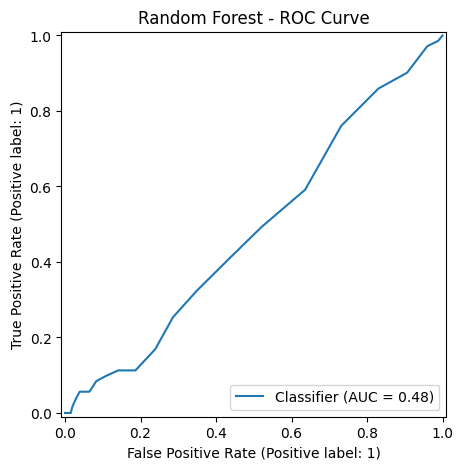

In [106]:
# step 8f - ROC Curve
fig, ax = plt.subplots(figsize=(6,5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    ax=ax
)

ax.set_title("Random Forest - ROC Curve")

plt.show()



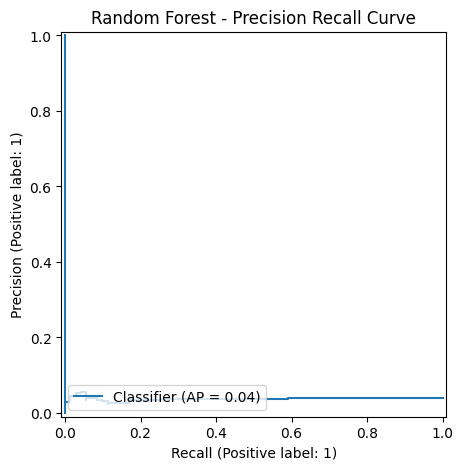

In [107]:
# step 8g -  Precision–Recall Curve
fig, ax = plt.subplots(figsize=(6,5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rf,
    ax=ax
)

ax.set_title("Random Forest - Precision Recall Curve")

plt.show()

### STEP 9 - XGBOOST Classifier 

In [108]:
# step 9a -  Build the Pipeline
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_estimators=200,
                learning_rate=0.1,
                max_depth=6
            )
        )
    ]
)

In [109]:
# step 9b - Train the Model
xgb_pipeline.fit(
    X_train,
    y_train
)
# Predictions
y_pred_xgb = xgb_pipeline.predict(X_test)

y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

In [110]:
# step 9c - Evaluate
xgb_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Score": [
        accuracy_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

xgb_results["Score"] = xgb_results["Score"].round(3)

xgb_results

,Metric,Score
0,Accuracy,0.961
1,Precision,0.000
2,Recall,0.000
3,F1 Score,0.000
4,ROC AUC,0.528


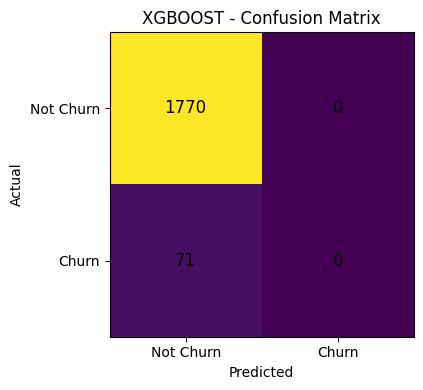

In [111]:
# step 9d -  Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(5,4))

im = ax.imshow(cm)

ax.set_title("XGBOOST - Confusion Matrix")

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

ax.set_xticks([0,1])
ax.set_yticks([0,1])

ax.set_xticklabels(["Not Churn","Churn"])
ax.set_yticklabels(["Not Churn","Churn"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
            fontsize=12
        )

plt.tight_layout()

plt.show()

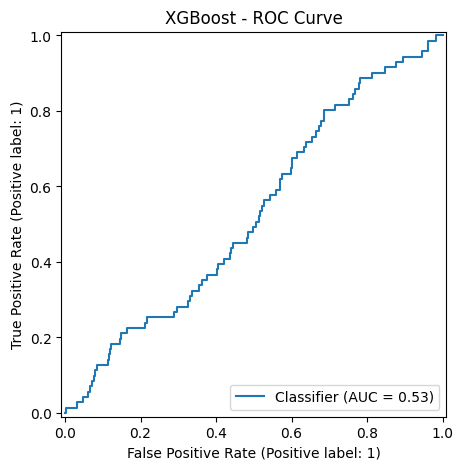

In [112]:
# step 9f -  ROC Curve
fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    ax=ax
)

ax.set_title("XGBoost - ROC Curve")

plt.show()


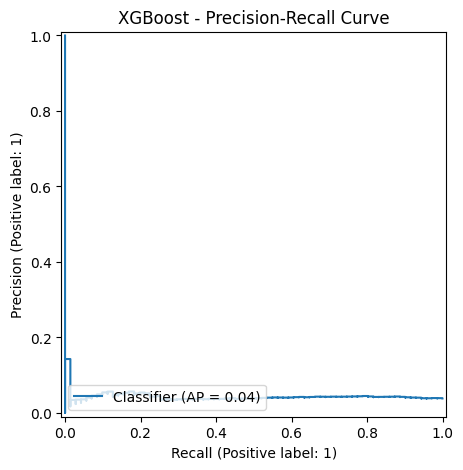

In [113]:
# step 9g - Precision–Recall Curve
fig, ax = plt.subplots(figsize=(6, 5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    ax=ax
)

ax.set_title("XGBoost - Precision-Recall Curve")

plt.show()

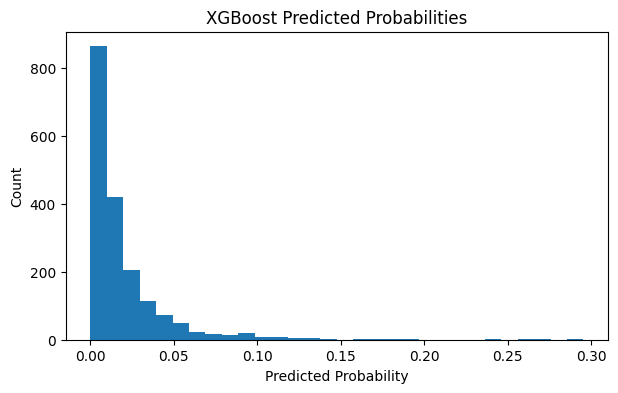

In [114]:
# step 9h -  probability distribution

plt.figure(figsize=(7,4))

plt.hist(
    y_prob_xgb,
    bins=30
)

plt.xlabel("Predicted Probability")

plt.ylabel("Count")

plt.title("XGBoost Predicted Probabilities")

plt.show()

### Step 10 — Compare All Baseline Models

- The three baseline models are compared using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Average Precision

- Because churn represents a small proportion of riders, accuracy is not sufficient on its own.

- ROC-AUC evaluates how well the model ranks churned riders above active riders across different thresholds.

- Average Precision summarizes performance on the minority churn class and is especially useful for imbalanced classification.



In [115]:

from sklearn.metrics import average_precision_score

# step 10a - step - Create one results table:

baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0),
        precision_score(y_test, y_pred_xgb, zero_division=0)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_xgb, zero_division=0)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_xgb, zero_division=0)
    ],

    "ROC AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],

    "Average Precision": [
        average_precision_score(y_test, y_prob_lr),
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_xgb)
    ]
})

baseline_results = baseline_results.round(3)

baseline_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Average Precision
0,Logistic Regression,0.498,0.041,0.535,0.076,0.517,0.038
1,Random Forest,0.961,0.000,0.000,0.000,0.484,0.037
2,XGBoost,0.961,0.000,0.000,0.000,0.528,0.043


In [116]:
# Step 10b — Rank the Models
 
# Models are ranked primarily using ROC-AUC because the objective is to rank riders according to their future churn risk.

# However, the practical difference between models must also be considered.

# A model should not be considered successful merely because it has the highest score when all models perform close to random classification.

ranked_results = (
    baseline_results
    .sort_values(
        by="ROC AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

ranked_results

# Add a rank column:

ranked_results.insert(
    0,
    "Rank",
    range(1, len(ranked_results) + 1)
)

ranked_results

,Rank,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Average Precision
0,1,XGBoost,0.961,0.000,0.000,0.000,0.528,0.043
1,2,Logistic Regression,0.498,0.041,0.535,0.076,0.517,0.038
2,3,Random Forest,0.961,0.000,0.000,0.000,0.484,0.037


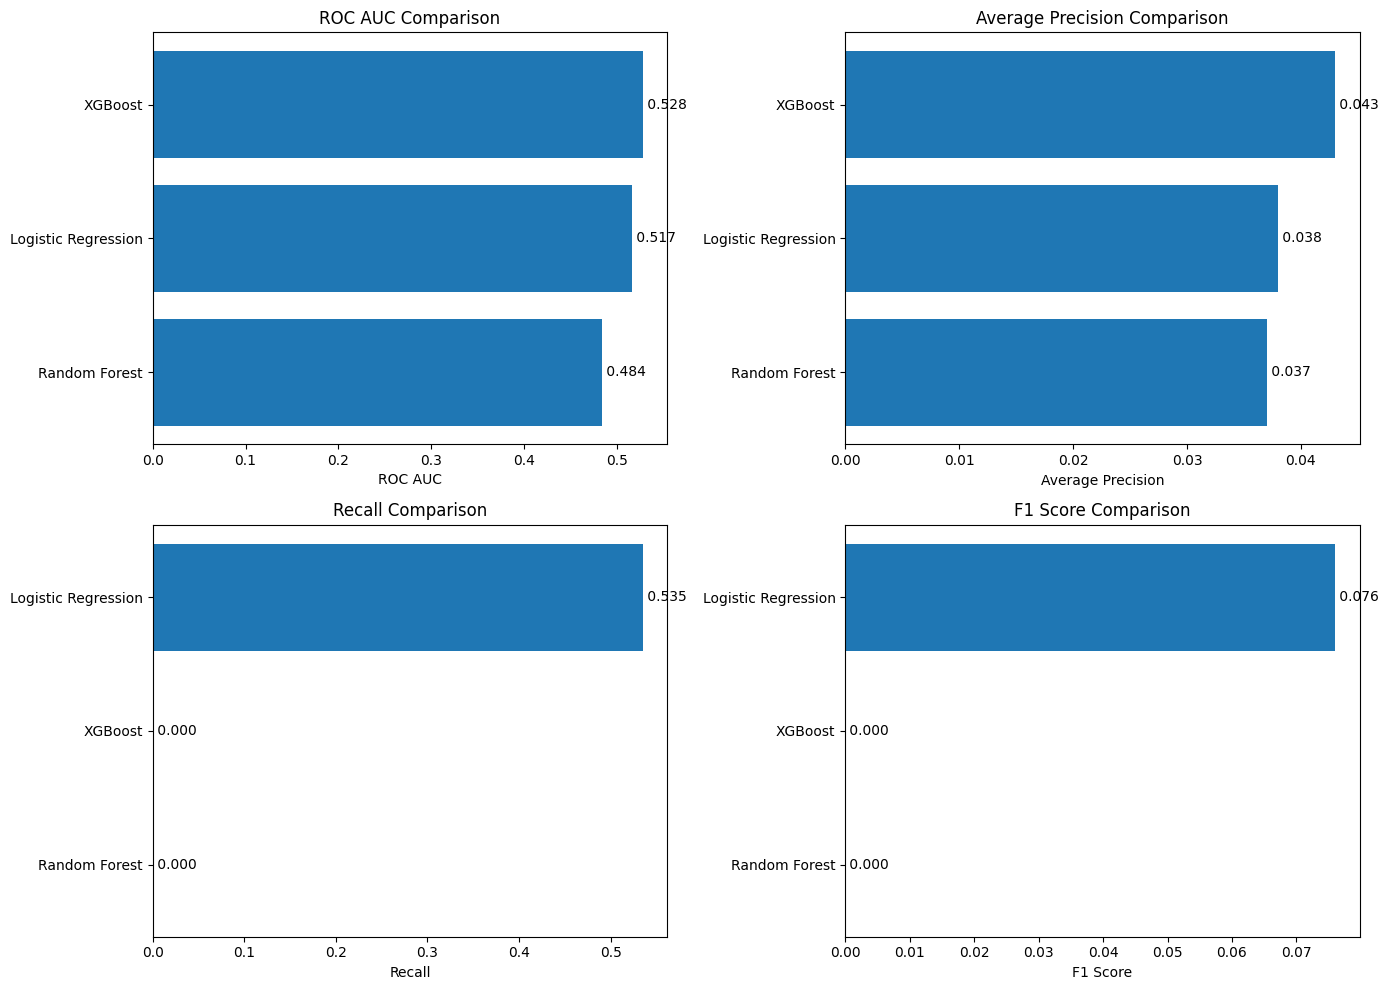

In [117]:
# step 10c - Model Performance Visualization

# The models are compared visually using ROC-AUC, Average Precision, Recall and F1-score.

# Scores close to 0.50 ROC-AUC indicate that a model is performing only slightly better than random ranking.

metrics_to_plot = [
    "ROC AUC",
    "Average Precision",
    "Recall",
    "F1 Score"
]

comparison_long = baseline_results.melt(
    id_vars="Model",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):

    metric_data = baseline_results[
        ["Model", metric]
    ].sort_values(metric)

    ax.barh(
        metric_data["Model"],
        metric_data[metric]
    )

    ax.set_title(f"{metric} Comparison")
    ax.set_xlabel(metric)

    for i, value in enumerate(metric_data[metric]):
        ax.text(
            value,
            i,
            f" {value:.3f}",
            va="center"
        )

plt.tight_layout()
plt.show()


### Tinsight:
- The three models produced very similar ROC-AUC scores close to 0.50.

- This indicates that increasing model complexity did not meaningfully improve the ability to distinguish future churners from active riders.

- Random Forest and XGBoost also predicted very few or no churned riders at the default 0.50 threshold, resulting in high accuracy but poor recall and F1-score.

- The high accuracy therefore reflects class imbalance rather than useful churn prediction.

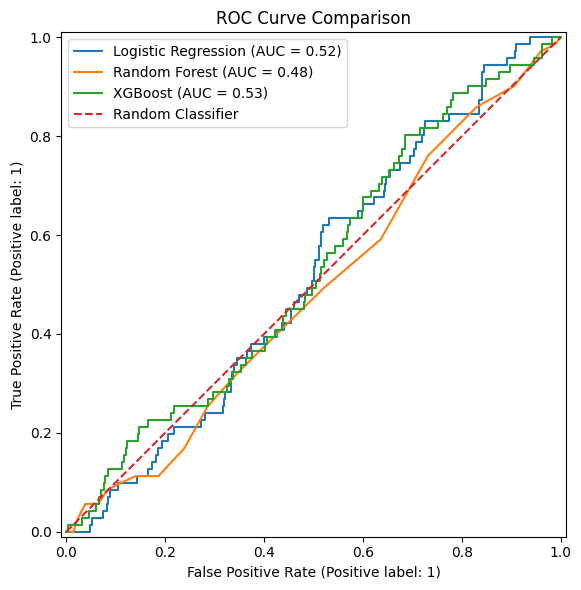

In [118]:
# step 10d - ROC Curve Comparison

# The ROC curves compare the ranking ability of all three models across different classification thresholds.

# The diagonal reference line represents random classification.

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost",
    ax=ax
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

ax.set_title("ROC Curve Comparison")
ax.legend()

plt.tight_layout()
plt.show()

- All three ROC curves remain close to the diagonal random-classifier line.

- This confirms that the models have limited ability to rank churned riders above active riders using the available historical features.

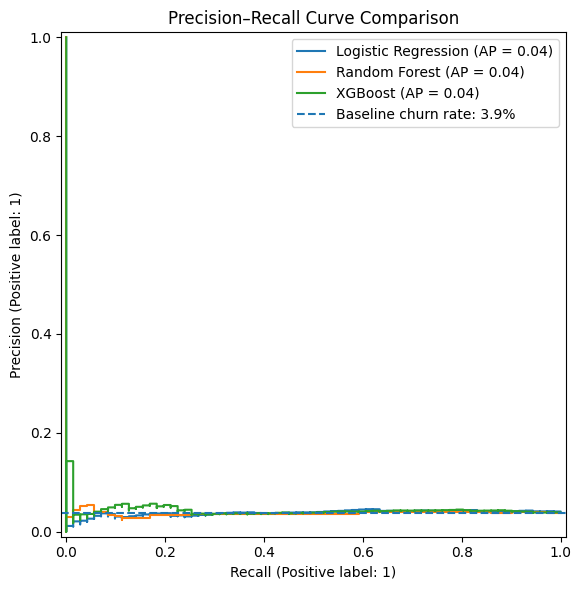

In [119]:

# step 10e -  Precision–Recall Curve Comparison

# Precision-Recall curves focus on performance for the minority churn class.

# The horizontal baseline represents the overall churn rate. 
# A useful model should maintain precision meaningfully above this baseline while achieving reasonable recall

churn_rate = y_test.mean()

fig, ax = plt.subplots(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost",
    ax=ax
)

ax.axhline(
    y=churn_rate,
    linestyle="--",
    label=f"Baseline churn rate: {churn_rate:.1%}"
)

ax.set_title("Precision–Recall Curve Comparison")
ax.legend()

plt.tight_layout()
plt.show()


### insight
- The Precision–Recall curves remain close to the churn-rate baseline.

- This means the models struggle to identify churned riders without generating a large number of false-positive alerts.

In [120]:
# step 10f -  Compare Churners and Active Riders

# Historical Behaviour by Churn Status

# To investigate why model performance was limited, key historical behaviours were compared between riders who remained active and riders who became inactive during the prediction window.

# If the two groups have very similar historical patterns, the models will have little information with which to separate them.com

mean_comparison = (
    df.groupby("churned")[
        [
            "frequency",
            "recency_days",
            "monetary_total",
            "average_fare",
            "account_age_days",
            "trips_last_30_days",
            "trips_last_60_days",
            "trips_last_90_days"
            
        ]
    ]
    .mean()
    .T
)

mean_comparison.columns = [
    "Active Riders",
    "Churned Riders"
]

mean_comparison["Absolute Difference"] = (
    mean_comparison["Churned Riders"] -
    mean_comparison["Active Riders"]
).abs()

mean_comparison.round(2)



,Active Riders,Churned Riders,Absolute Difference
frequency,16.73,16.49,0.24
recency_days,17.74,17.88,0.14
monetary_total,257.59,255.19,2.40
average_fare,15.39,15.46,0.07
account_age_days,334.12,328.34,5.78
trips_last_30_days,1.66,1.62,0.04
trips_last_60_days,3.31,3.18,0.13
trips_last_90_days,4.95,4.79,0.15


### Insight

-The historical behaviour of churned and active riders was nearly identical.

- For example:

- Lifetime trip frequency differed only slightly.
- Recency was almost the same across both groups.
- Total spending and average fare were very similar.
- Recent 30-day and 60-day trip activity showed minimal separation.
- Account age was also comparable.

- These results explain why Logistic Regression, Random Forest and XGBoost all achieved ROC-AUC scores close to random classification.

- The available features do not contain a sufficiently strong historical pattern associated with future inactivity.

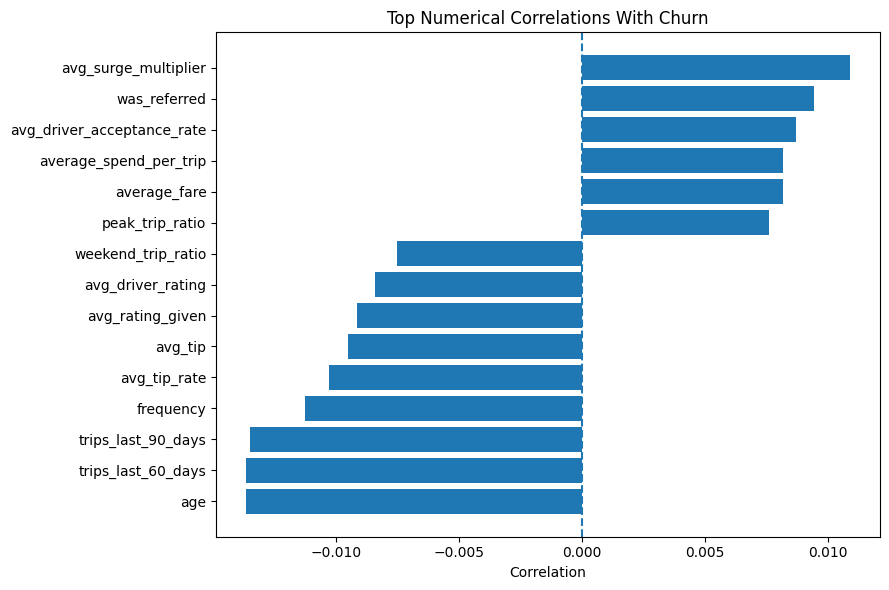

In [121]:
# step 10g - Correlation With Churn

# Point-biserial correlation is represented here using the standard Pearson correlation between numerical features and the binary churn target.

# Very small absolute correlations suggest weak linear separation between churned and active riders.

numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

churn_correlations = (
    df[numeric_columns]
    .corr()["churned"]
    .drop("churned")
    .sort_values(
        key=abs,
        ascending=False
    )
)
            

churn_correlations

# Visualize the strongest correlations:

top_correlations = (
    churn_correlations
    .head(15)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    top_correlations.index,
    top_correlations.values
)

ax.axvline(
    0,
    linestyle="--"
)

ax.set_title("Top Numerical Correlations With Churn")
ax.set_xlabel("Correlation")

plt.tight_layout()
plt.show()



### insight
- Most numerical features showed correlations close to zero.

- This does not prove that all possible nonlinear relationships are absent. However, when combined with weak performance from both linear and tree-based models, it provides further evidence that the dataset contains limited predictive churn signal.

###  STEP 11 - Select Best Model

In [122]:
# Step 11a  — Select the Best Available Model

# We are selecting it for explainability, not claiming it is production-ready.

# XGBoost achieved the highest ROC-AUC among the evaluated models.

# However, its improvement over Logistic Regression and Random Forest was very small and was not practically meaningful.

# XGBoost is therefore retained only as the best available model for diagnostic explainability. It is not recommended for operational deployment.
    
    
best_model = xgb_pipeline

best_model_name = "XGBoost"

Best_model_name = ranked_results.loc[0, "Model"]

print("Best available model:", best_model_name)

# Create a dictionary:

model_probabilities = {
    "Logistic Regression": y_prob_lr,
    "Random Forest": y_prob_rf,
    "XGBoost": y_prob_xgb
}

best_proba = model_probabilities[best_model_name]


Best available model: XGBoost


In [123]:
# step 11b - Check its AUC:

best_model_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

print(f"Selected model: {best_model_name}")
print(f"Test ROC-AUC: {best_model_auc:.4f}")


Selected model: XGBoost
Test ROC-AUC: 0.5278


In [124]:
# Step 11c — Save Model and Supporting Objects

# Create a model path:

MODEL_DIR = os.path.join(
    "..",
    "models"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

# Save the fitted pipeline:

joblib.dump(
    best_model,
    os.path.join(
        MODEL_DIR,
        "ridewise_xgboost_diagnostic_pipeline.pkl"
    )
)

# Save test data for explainability:

X_test.to_csv(
    os.path.join(
        DATA_PROCESSED,
        "ridewise_X_test.csv"
    ),
    index=False
)

y_test.to_csv(
    os.path.join(
        DATA_PROCESSED,
        "ridewise_y_test.csv"
    ),
    index=False
)

# Validate:

print("Diagnostic model and test data saved successfully.")


Diagnostic model and test data saved successfully.



### Step 25 — Final Modelling Conclusion




This project evaluated whether historical rider behaviour could predict inactivity during a future 60-day prediction window.

Three classification algorithms were trained and evaluated:

- Logistic Regression
- Random Forest
- XGBoost

All three models achieved ROC-AUC scores close to 0.50, indicating limited ability to distinguish riders who became inactive from those who remained active.

Further investigation showed that churned and active riders had nearly identical historical:

- Trip frequency
- Recency
- Total spending
- Average fare
- Account age
- Trips during the most recent 30 days
- Trips during the most recent 60 days

- The consistency of the results across linear, bagging and boosting algorithms suggests that model complexity was not the main limitation.

- Instead, the available data did not contain a sufficiently strong relationship between historical rider behaviour and future inactivity.

### Business Decision

- The churn model should not be deployed for automated customer-retention decisions in its current form.

- Deploying the model could generate large numbers of false-positive alerts and inefficient retention spending.

###  Data Required for Future Improvement

- A future modelling iteration would benefit from:

- Longer session-history coverage
- Customer-support complaints
- Promotion-response history
- App-search and booking-abandonment behaviour
- Payment failures
- Fare-sensitivity indicators
- Service-quality incidents
- Competitor or geographic availability
- Explicit cancellation or account-closure outcomes
- Repeated historical churn observation windows

###  Portfolio Outcome

- Although the model was not deployment-ready, the project successfully demonstrates:

- Temporal target definition
- Prevention of future-data leakage
- Historical-only feature engineering
- Imbalanced classification
- Pipeline-based preprocessing
- Comparison of multiple model families
- Investigation of weak model performance
- Evidence-based decision not to deploy an unreliable model

- The next stage uses explainability as a diagnostic tool to understand how the best available model generated its predictions. Inter